## Section 1  Study question and setup

Item,Value
Rows in dataset,943
Failure rate,0.417
Target column,fail
Train split approach,train / validation / test
Check cost per machine,10.0
Base missed failure loss,500.0
Recovery rate,1.0
Severity shrink alpha,0.50
Surge extra cost per check,5.0
Surge fixed activation cost,100.0


Staffing level label,Rule
smallest,5 to 20
medium,25 to 45
large,50 to 75
surge,98 to 108 (90% to 100% of urgent queue)


## Section 2  Method and fixed rule

Staffing level is the main object.
Labels such as smallest, medium, large, and surge are used only to interpret the staffing level path.
Fixed urgent threshold within each candidate.
Severity learned from training only.



Model,Weight,PR AUC,PR std,ROC AUC,ROC std
Extra Trees,balanced_x1.5,0.962,0.015,0.968,0.011
Extra Trees,balanced_x1.25,0.961,0.017,0.968,0.013
Extra Trees,balanced,0.961,0.016,0.968,0.011
Extra Trees,balanced_x0.75,0.961,0.015,0.968,0.011
Extra Trees,none,0.961,0.015,0.968,0.011
SVM RBF,balanced,0.960,0.014,0.967,0.010
SVM RBF,none,0.959,0.013,0.965,0.009
SVM RBF,balanced_x0.75,0.959,0.013,0.965,0.009


## Section 3  Normal operations results

Model,Weight,Calibration,Threshold,Urgent queue size,Best normal staffing level,Best normal staffing level label,Best normal net value,Mean normal net value,Min normal net value,Best normal precision,Best normal recall
Extra Trees,none,none,0.029,108,95,large,38816.759,15687.463,-38687.503,0.611,0.983


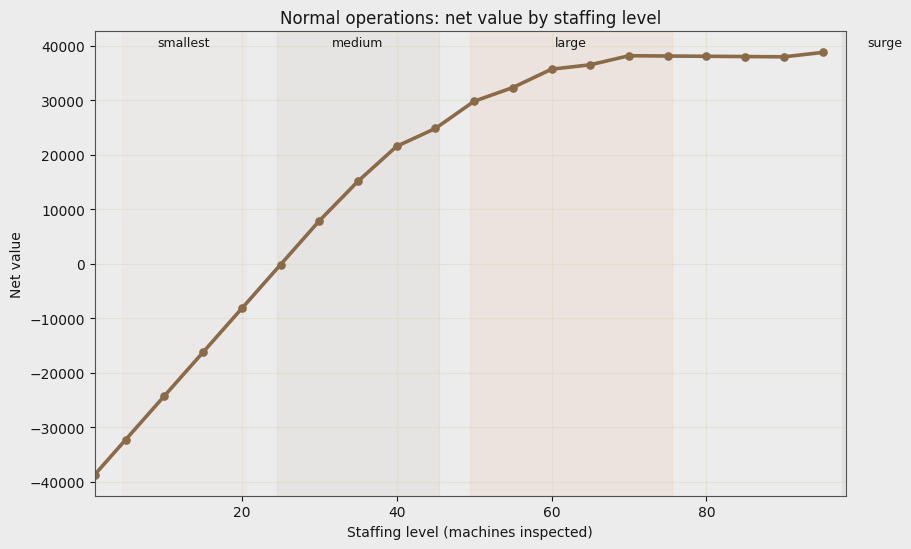

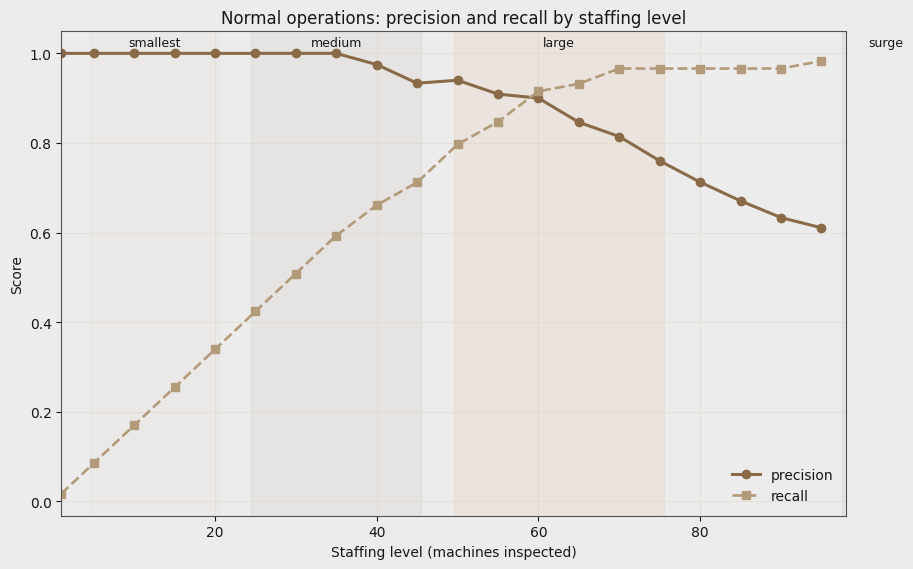

## Section 4  Emergency surge check

Model,Weight,Calibration,Threshold,Mean surge net value,Min surge net value
Extra Trees,balanced_x0.75,none,0.035,38352.503,38166.759


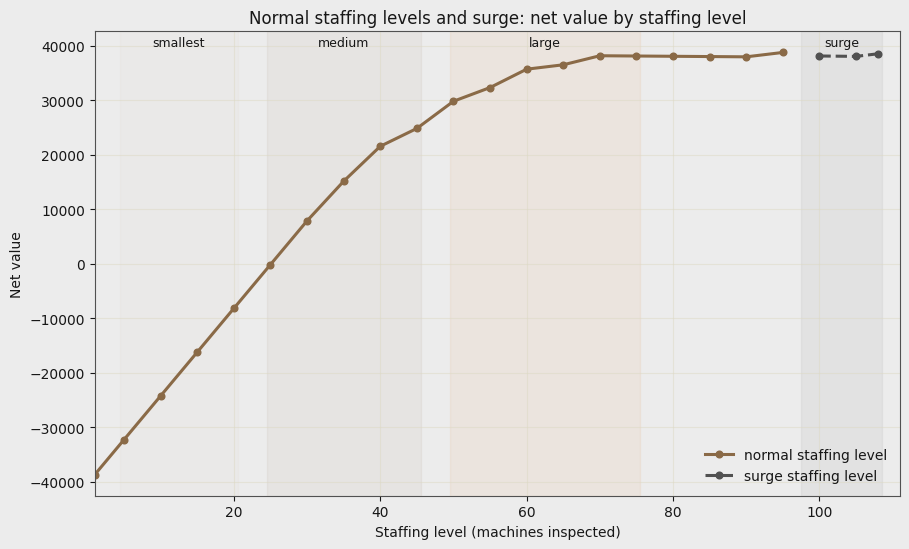

Interpretation: section 4 adds surge to the same staffing level path so you can see where emergency mode begins.


## Final normal recommendation

Model,Weight,Threshold,Best staffing level,Staffing level label,Mean normal net value,Min normal net value,Best normal precision,Best normal recall
Extra Trees,none,0.029,95,large,15687.463,-38687.503,0.611,0.983


## Locked test summary

Model,Weight,Threshold,Test staffing level,Test staffing level label,Test net value,Test precision,Test recall,ROC AUC,PR AUC,Brier,ECE
Extra Trees,none,0.029,106,large,42176.527,0.557,1.000,0.979,0.966,0.057,0.086


## Queue preview only

Machine,Rank,Pred prob,Severity,Urgent,Fail,Action
23,1,0.999,High,True,1,Inspect now
97,2,0.999,High,True,1,Inspect now
111,3,0.999,High,True,1,Inspect now
11,4,0.998,High,True,1,Inspect now
133,5,0.997,High,True,1,Inspect now
115,6,0.997,High,True,1,Inspect now
61,7,0.996,High,True,1,Inspect now
82,8,0.996,High,True,1,Inspect now
75,9,0.996,High,True,1,Inspect now
123,10,0.994,High,True,1,Inspect now


## Done

Wrote locked_test_queue.csv
Wrote locked_test_summary.csv
Staffing level is now the main object.
Labels are used only for interpretation.
Normal staffing level labels: smallest, medium, large.
Surge staffing level label: 90% to 100% of urgent queue.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize_scalar
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = str

try:
    from venn_abers import VennAbersCalibrator
    HAS_VENN_ABERS = True
except Exception:
    HAS_VENN_ABERS = False


# =========================================================
# SETTINGS
# =========================================================
RANDOM_STATE = 42
DATA_PATH = "/kaggle/input/datasets/umerrtx/machine-failure-prediction-using-sensor-data/data.csv"
TARGET = "fail"

TEST_SIZE = 0.15
VALIDATION_SHARE_OF_REMAINDER = 0.17647058823529413

ROW_CHECK_COST = 10.0
BASE_MISSED_LOSS = 500.0
RECOVERY_RATE = 1.0
SEVERITY_SHRINK_ALPHA = 0.50

BOOTSTRAP_ROUNDS = 50
N_SPLITS = 4
TOP_CANDIDATES = 8
QUEUE_PREVIEW_ROWS = 10
CAPACITY_STEP = 5

SURGE_EXTRA_PER_CHECK = 5.0
SURGE_FIXED_ACTIVATION_COST = 100.0
SURGE_SHARE_START = 0.90

WEIGHT_STYLES = ["none", "balanced_x0.75", "balanced", "balanced_x1.25", "balanced_x1.5"]
MODELS = ["Logistic Regression", "Random Forest", "Extra Trees", "SVM RBF"]

MODE_USED = "staffing_level_first_with_3_normal_ranges_plus_surge"


# =========================================================
# NOTEBOOK STYLE
# =========================================================
PALETTE = {
    "bg": "#ececec",
    "grid": "#ddd9c3",
    "stone": "#c3c3c3",
    "sand": "#d6c6a8",
    "taupe": "#b39b7a",
    "cocoa": "#8a6a47",
    "copper": "#b66a2c",
    "amber": "#e46f0a",
    "slate": "#515151",
    "ink": "#171717",

    "smallest": "#d6c6a8",
    "medium": "#8a6a47",
    "large": "#e46f0a",
    "surge": "#515151",
}

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 160)


def apply_plot_style():
    plt.rcParams["figure.facecolor"] = PALETTE["bg"]
    plt.rcParams["axes.facecolor"] = PALETTE["bg"]
    plt.rcParams["savefig.facecolor"] = PALETTE["bg"]
    plt.rcParams["axes.edgecolor"] = PALETTE["slate"]
    plt.rcParams["axes.labelcolor"] = PALETTE["ink"]
    plt.rcParams["xtick.color"] = PALETTE["ink"]
    plt.rcParams["ytick.color"] = PALETTE["ink"]
    plt.rcParams["text.color"] = PALETTE["ink"]
    plt.rcParams["grid.color"] = PALETTE["grid"]
    plt.rcParams["grid.alpha"] = 0.50
    plt.rcParams["axes.titleweight"] = "regular"


apply_plot_style()


def show_title(text: str):
    try:
        display(Markdown(f"## {text}"))
    except Exception:
        print("\n" + text)


def style_table(df: pd.DataFrame, decimals: int = 3):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        out[num_cols] = out[num_cols].round(decimals)

    try:
        return (
            out.style
            .hide(axis="index")
            .format(precision=decimals)
            .set_table_styles([
                {"selector": "table", "props": [
                    ("background-color", PALETTE["bg"]),
                    ("color", PALETTE["ink"]),
                    ("border-collapse", "collapse"),
                    ("font-size", "14px"),
                    ("line-height", "1.25"),
                ]},
                {"selector": "th", "props": [
                    ("background-color", PALETTE["bg"]),
                    ("color", PALETTE["ink"]),
                    ("font-weight", "600"),
                    ("padding", "8px 10px"),
                    ("border-bottom", f"1px solid {PALETTE['stone']}"),
                    ("white-space", "normal"),
                    ("text-align", "left"),
                ]},
                {"selector": "td", "props": [
                    ("padding", "8px 10px"),
                    ("white-space", "nowrap"),
                    ("text-align", "left"),
                ]},
            ])
        )
    except Exception:
        return out


def show_table(df: pd.DataFrame, cols=None, rename=None, sort_by=None, ascending=False, decimals=3):
    out = df.copy()
    if cols is not None:
        out = out[cols].copy()
    if rename is not None:
        out = out.rename(columns=rename)
    if sort_by is not None:
        out = out.sort_values(sort_by, ascending=ascending).reset_index(drop=True)
    display(style_table(out, decimals=decimals))


# =========================================================
# HELPERS
# =========================================================
def clip_probs(p):
    return np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)


def current_surge_premium():
    return SURGE_EXTRA_PER_CHECK


def current_surge_fixed_cost():
    return SURGE_FIXED_ACTIVATION_COST


def make_capacity_grid(urgent_total: int, step: int = CAPACITY_STEP):
    urgent_total = int(max(urgent_total, 1))
    pts = list(range(step, urgent_total + 1, step))
    if 1 not in pts:
        pts = [1] + pts
    if urgent_total not in pts:
        pts.append(urgent_total)
    return sorted(set([p for p in pts if 1 <= p <= urgent_total]))


def surge_start_capacity(urgent_total: int) -> int:
    return max(1, int(math.ceil(urgent_total * SURGE_SHARE_START)))


def capacity_label(capacity: int, urgent_total: int) -> str:
    surge_start = surge_start_capacity(urgent_total)
    if capacity >= surge_start:
        return "surge"
    if capacity <= 20:
        return "smallest"
    if capacity <= 45:
        return "medium"
    return "large"


def capacity_label_table(urgent_total: int) -> pd.DataFrame:
    surge_start = surge_start_capacity(urgent_total)
    return pd.DataFrame({
        "Staffing level label": ["smallest", "medium", "large", "surge"],
        "Rule": [
            "5 to 20",
            "25 to 45",
            "50 to 75",
            f"{surge_start} to {urgent_total}  (90% to 100% of urgent queue)",
        ],
    })


def calibration_stats(y_true, scores, n_bins=10):
    y_true = np.asarray(y_true, dtype=int)
    scores = clip_probs(scores)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(scores, bins[1:-1], right=True)

    ece = 0.0
    max_gap = 0.0
    n = len(scores)

    for b in range(n_bins):
        mask = bin_ids == b
        count = int(mask.sum())
        if count == 0:
            continue
        avg_pred = float(scores[mask].mean())
        avg_true = float(y_true[mask].mean())
        gap = abs(avg_true - avg_pred)
        ece += (count / n) * gap
        max_gap = max(max_gap, gap)

    return float(ece), float(max_gap)


# =========================================================
# SEVERITY
# =========================================================
def select_severity_features(X_train: pd.DataFrame, y_train: pd.Series, bootstrap_rounds: int):
    y_num = y_train.astype(float).reset_index(drop=True)
    X_part = X_train.reset_index(drop=True)
    rng = np.random.default_rng(RANDOM_STATE)
    rows = []

    for col in X_part.columns:
        corr = pd.Series(X_part[col]).corr(y_num, method="spearman")
        corr = 0.0 if pd.isna(corr) else float(corr)

        n = len(X_part)
        boot_corrs = []
        for _ in range(bootstrap_rounds):
            idx = rng.integers(0, n, size=n)
            c = pd.Series(X_part.iloc[idx][col]).corr(pd.Series(y_num.iloc[idx]), method="spearman")
            c = 0.0 if pd.isna(c) else float(c)
            boot_corrs.append(c)

        rows.append({
            "feature": col,
            "spearman_with_fail": corr,
            "bootstrap_mean_abs_corr": float(np.mean(np.abs(boot_corrs))),
            "sign_agreement": float(np.mean(np.sign(boot_corrs) == np.sign(corr))) if corr != 0 else 1.0,
        })

    feature_table = pd.DataFrame(rows).sort_values(
        ["bootstrap_mean_abs_corr", "sign_agreement", "feature"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    keep = feature_table[
        (feature_table["bootstrap_mean_abs_corr"] >= 0.04) &
        (feature_table["sign_agreement"] >= 0.80)
    ].copy()

    if keep.empty:
        keep = feature_table.head(min(5, len(feature_table))).copy()

    keep = keep.sort_values(
        ["bootstrap_mean_abs_corr", "sign_agreement", "feature"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    selected = []
    for _, row in keep.iterrows():
        feat = row["feature"]
        if not selected:
            selected.append(feat)
            continue
        max_abs_corr = max(abs(X_train[feat].corr(X_train[s], method="spearman")) for s in selected)
        if pd.isna(max_abs_corr) or max_abs_corr < 0.95:
            selected.append(feat)

    keep = keep[keep["feature"].isin(selected)].copy().reset_index(drop=True)
    keep["weight"] = keep["bootstrap_mean_abs_corr"] / keep["bootstrap_mean_abs_corr"].sum()
    return feature_table, keep


class SeverityScorer:
    def __init__(self, keep_table: pd.DataFrame, shrink_alpha: float = 1.0):
        self.keep_table = keep_table.copy()
        self.shrink_alpha = float(shrink_alpha)
        self.scaler = StandardScaler()
        self.edges = None
        self.raw_multiplier_map = None
        self.multiplier_map = None

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series):
        feats = self.keep_table["feature"].tolist()
        self.scaler.fit(X_train[feats])

        train_scores = self.score(X_train)
        self.edges = np.quantile(train_scores, [1 / 3, 2 / 3])

        labels = self.labels_from_scores(train_scores)
        tmp = pd.DataFrame({"severity": labels, "fail": y_train.values})
        overall_fail_rate = float(y_train.mean())

        rates = tmp.groupby("severity")["fail"].mean().reindex(["Low", "Medium", "High"])
        self.raw_multiplier_map = (rates / overall_fail_rate).to_dict()
        self.multiplier_map = {
            k: float(1.0 + self.shrink_alpha * (v - 1.0))
            for k, v in self.raw_multiplier_map.items()
        }
        return self

    def score(self, X_raw: pd.DataFrame) -> np.ndarray:
        feats = self.keep_table["feature"].tolist()
        X_scaled = pd.DataFrame(
            self.scaler.transform(X_raw[feats]),
            columns=feats,
            index=X_raw.index,
        )

        score = np.zeros(len(X_scaled), dtype=float)
        for _, row in self.keep_table.iterrows():
            sign = 1.0 if row["spearman_with_fail"] >= 0 else -1.0
            score += X_scaled[row["feature"]].to_numpy(dtype=float) * float(row["weight"]) * sign
        return score

    def labels_from_scores(self, scores: np.ndarray) -> pd.Series:
        bins = np.digitize(scores, bins=self.edges, right=True)
        return pd.Series(np.array(["Low", "Medium", "High"])[bins])

    def labels(self, X_raw: pd.DataFrame) -> pd.Series:
        return self.labels_from_scores(self.score(X_raw))

    def value_table(self, severity_labels: pd.Series) -> pd.DataFrame:
        sev_mult = pd.Series(severity_labels).map(self.multiplier_map).astype(float).values
        row_missed_loss = BASE_MISSED_LOSS * sev_mult
        row_saved_value = row_missed_loss * RECOVERY_RATE
        return pd.DataFrame({
            "row_check_cost": np.full(len(severity_labels), ROW_CHECK_COST, dtype=float),
            "row_missed_loss": row_missed_loss,
            "row_saved_value": row_saved_value,
        })


# =========================================================
# MODELS
# =========================================================
def make_class_weight(style: str, y_train: pd.Series):
    if style == "none":
        return None
    pos_weight = (len(y_train) - int(y_train.sum())) / max(int(y_train.sum()), 1)
    mult = {
        "balanced_x0.75": 0.75,
        "balanced": 1.00,
        "balanced_x1.25": 1.25,
        "balanced_x1.5": 1.50,
    }[style]
    return {0: 1.0, 1: float(mult * pos_weight)}


def build_base_estimator(model_name: str, class_weight):
    if model_name == "Logistic Regression":
        return Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,
                solver="lbfgs",
                random_state=RANDOM_STATE,
                class_weight=class_weight,
            )),
        ])
    if model_name == "Random Forest":
        return Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=220,
                min_samples_leaf=2,
                class_weight=class_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ])
    if model_name == "Extra Trees":
        return Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("model", ExtraTreesClassifier(
                n_estimators=280,
                min_samples_leaf=2,
                class_weight=class_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ])
    if model_name == "SVM RBF":
        return Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                probability=True,
                class_weight=class_weight,
                random_state=RANDOM_STATE,
            )),
        ])
    raise ValueError(f"Unknown model name: {model_name}")


def cv_model_search(X_train: pd.DataFrame, y_train: pd.Series) -> pd.DataFrame:
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    rows = []

    for model_name in MODELS:
        for weight_style in WEIGHT_STYLES:
            class_weight = make_class_weight(weight_style, y_train)
            fold_roc, fold_pr = [], []

            for fit_idx, score_idx in cv.split(X_train, y_train):
                X_fit = X_train.iloc[fit_idx]
                y_fit = y_train.iloc[fit_idx]
                X_score = X_train.iloc[score_idx]
                y_score = y_train.iloc[score_idx]

                model = build_base_estimator(model_name, class_weight)
                model.fit(X_fit, y_fit)
                prob = clip_probs(model.predict_proba(X_score)[:, 1])

                fold_roc.append(roc_auc_score(y_score, prob))
                fold_pr.append(average_precision_score(y_score, prob))

            rows.append({
                "model": model_name,
                "weight_style": weight_style,
                "cv_pr_auc_mean": float(np.mean(fold_pr)),
                "cv_pr_auc_std": float(np.std(fold_pr)),
                "cv_roc_auc_mean": float(np.mean(fold_roc)),
                "cv_roc_auc_std": float(np.std(fold_roc)),
            })

    return pd.DataFrame(rows).sort_values(
        ["cv_pr_auc_mean", "cv_roc_auc_mean", "cv_pr_auc_std", "cv_roc_auc_std"],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)


def build_oof_raw_scores(X_train, y_train, model_name, weight_style):
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(X_train), dtype=float)

    for fit_idx, hold_idx in cv.split(X_train, y_train):
        X_fit = X_train.iloc[fit_idx]
        y_fit = y_train.iloc[fit_idx]
        X_hold = X_train.iloc[hold_idx]
        class_weight = make_class_weight(weight_style, y_fit)
        model = build_base_estimator(model_name, class_weight)
        model.fit(X_fit, y_fit)
        oof[hold_idx] = clip_probs(model.predict_proba(X_hold)[:, 1])

    return oof


# =========================================================
# CALIBRATION
# =========================================================
def fit_temperature_scaler(raw_scores, y_true):
    p = clip_probs(raw_scores)
    logits = np.log(p / (1.0 - p))
    y = np.asarray(y_true, dtype=float)

    def objective(temp):
        temp = max(float(temp), 1e-3)
        scaled = 1.0 / (1.0 + np.exp(-logits / temp))
        scaled = clip_probs(scaled)
        return float(-np.mean(y * np.log(scaled) + (1.0 - y) * np.log(1.0 - scaled)))

    return float(minimize_scalar(objective, bounds=(0.05, 10.0), method="bounded").x)


def apply_temperature_scaler(temp, raw_scores):
    p = clip_probs(raw_scores)
    logits = np.log(p / (1.0 - p))
    scaled = 1.0 / (1.0 + np.exp(-logits / max(float(temp), 1e-3)))
    return clip_probs(scaled)


def fit_histogram_binning(raw_scores, y_true, n_bins=5):
    p = clip_probs(raw_scores)
    y = np.asarray(y_true, dtype=float)

    quantiles = np.linspace(0.0, 1.0, n_bins + 1)
    edges = np.quantile(p, quantiles)
    edges[0], edges[-1] = 0.0, 1.0

    for i in range(1, len(edges)):
        if edges[i] <= edges[i - 1]:
            edges[i] = min(edges[i - 1] + 1e-8, 1.0)

    bin_ids = np.digitize(p, edges[1:-1], right=True)
    global_rate = float(y.mean())
    bin_rates = np.array([
        global_rate if (bin_ids == b).sum() == 0 else float(y[bin_ids == b].mean())
        for b in range(n_bins)
    ], dtype=float)

    return {"edges": edges, "bin_rates": bin_rates}


def apply_histogram_binning(calibrator, raw_scores):
    p = clip_probs(raw_scores)
    bin_ids = np.digitize(p, calibrator["edges"][1:-1], right=True)
    return clip_probs(np.array([calibrator["bin_rates"][b] for b in bin_ids], dtype=float))


def fit_venn_abers_model(model_name, weight_style, X_train, y_train):
    class_weight = make_class_weight(weight_style, y_train)
    estimator = build_base_estimator(model_name, class_weight)
    va = VennAbersCalibrator(
        estimator=estimator,
        inductive=True,
        cal_size=0.2,
        random_state=RANDOM_STATE,
    )
    va.fit(X_train, y_train)
    return va


def choose_calibration(X_train, y_train, X_validation, y_validation, model_name, weight_style):
    oof_raw = build_oof_raw_scores(
        X_train.reset_index(drop=True),
        y_train.reset_index(drop=True),
        model_name,
        weight_style,
    )

    class_weight = make_class_weight(weight_style, y_train)
    full_model = build_base_estimator(model_name, class_weight)
    full_model.fit(X_train, y_train)
    validation_raw = clip_probs(full_model.predict_proba(X_validation)[:, 1])

    candidates = {
        "none": validation_raw,
        "temperature": apply_temperature_scaler(
            fit_temperature_scaler(oof_raw, y_train.reset_index(drop=True).values),
            validation_raw,
        ),
        "histogram_5bin": apply_histogram_binning(
            fit_histogram_binning(oof_raw, y_train.reset_index(drop=True).values, n_bins=5),
            validation_raw,
        ),
    }

    if HAS_VENN_ABERS:
        va = fit_venn_abers_model(
            model_name,
            weight_style,
            X_train.reset_index(drop=True),
            y_train.reset_index(drop=True),
        )
        candidates["venn_abers"] = clip_probs(va.predict_proba(X_validation)[:, 1])

    rows = []
    for method, prob in candidates.items():
        ece, max_gap = calibration_stats(y_validation, prob)
        rows.append({
            "calibration": method,
            "validation_brier": float(brier_score_loss(y_validation, prob)),
            "validation_ece": float(ece),
            "validation_max_gap": float(max_gap),
        })

    summary = pd.DataFrame(rows).sort_values(
        ["validation_brier", "validation_ece", "validation_max_gap"],
        ascending=[True, True, True],
    ).reset_index(drop=True)

    winning_calibration = str(summary.iloc[0]["calibration"])
    return summary, winning_calibration, full_model, candidates[winning_calibration]


# =========================================================
# VALUE TABLES
# =========================================================
def build_threshold_table(y_true, scores, value_table):
    table = value_table.copy().reset_index(drop=True)
    table["actual_failure"] = np.asarray(y_true, dtype=int)
    table["score"] = np.asarray(scores, dtype=float)
    table = table.sort_values("score", ascending=False).reset_index(drop=True)

    total_failures = max(int(table["actual_failure"].sum()), 1)
    rows = []

    for k in range(1, len(table) + 1):
        urgent = table.iloc[:k]
        backlog = table.iloc[k:]

        saved_failure_value = float(urgent.loc[urgent["actual_failure"] == 1, "row_saved_value"].sum())
        check_cost = float(urgent["row_check_cost"].sum())
        missed_failure_cost = float(backlog.loc[backlog["actual_failure"] == 1, "row_missed_loss"].sum())
        tp = int(urgent["actual_failure"].sum())

        rows.append({
            "threshold": float(table.loc[k - 1, "score"]),
            "urgent_total": int(k),
            "net_value": saved_failure_value - check_cost - missed_failure_cost,
            "precision": tp / max(k, 1),
            "recall": tp / total_failures,
        })

    return pd.DataFrame(rows)


def build_capacity_table(
    y_true,
    scores,
    value_table,
    threshold,
    surge_mode_active=False,
    surge_extra_per_check=0.0,
    surge_fixed_activation_cost=0.0,
):
    queue = value_table.copy().reset_index(drop=True)
    queue["actual_failure"] = np.asarray(y_true, dtype=int)
    queue["score"] = np.asarray(scores, dtype=float)
    queue = queue[queue["score"] >= threshold].sort_values("score", ascending=False).reset_index(drop=True)

    total_urgent_failures = max(int(queue["actual_failure"].sum()), 1)
    rows = []

    for k in range(1, len(queue) + 1):
        do_today = queue.iloc[:k]
        backlog = queue.iloc[k:]

        saved_failure_value = float(do_today.loc[do_today["actual_failure"] == 1, "row_saved_value"].sum())
        base_check_cost = float(do_today["row_check_cost"].sum())
        surge_premium_cost = float(k * surge_extra_per_check) if surge_mode_active else 0.0
        surge_activation_cost = float(surge_fixed_activation_cost) if surge_mode_active and k > 0 else 0.0
        total_check_cost = base_check_cost + surge_premium_cost + surge_activation_cost
        missed_failure_cost = float(backlog.loc[backlog["actual_failure"] == 1, "row_missed_loss"].sum())

        rows.append({
            "capacity": int(k),
            "base_check_cost": float(base_check_cost),
            "surge_premium_cost": float(surge_premium_cost),
            "surge_activation_cost": float(surge_activation_cost),
            "total_check_cost": float(total_check_cost),
            "missed_failure_cost": float(missed_failure_cost),
            "net_value": float(saved_failure_value - total_check_cost - missed_failure_cost),
            "today_precision": float(do_today["actual_failure"].mean()),
            "today_recall_within_urgent_pool": float(do_today["actual_failure"].sum() / total_urgent_failures),
        })

    return queue, pd.DataFrame(rows)


def evaluate_candidate_capacity_first(X_train, y_train, X_validation, y_validation, validation_values, model_name, weight_style):
    calibration_summary, winning_calibration, _, validation_prob = choose_calibration(
        X_train, y_train, X_validation, y_validation, model_name, weight_style
    )

    threshold_table = build_threshold_table(y_validation, validation_prob, validation_values)
    best_threshold_row = threshold_table.sort_values(
        ["net_value", "recall", "precision"],
        ascending=[False, False, False],
    ).iloc[0]
    candidate_threshold = float(best_threshold_row["threshold"])

    queue, _ = build_capacity_table(
        y_validation,
        validation_prob,
        validation_values,
        candidate_threshold,
        surge_mode_active=False,
        surge_extra_per_check=0.0,
        surge_fixed_activation_cost=0.0,
    )

    urgent_total = len(queue)
    grid = make_capacity_grid(urgent_total)

    sampled_rows = []
    for k in grid:
        is_surge = k >= surge_start_capacity(urgent_total)
        do_today = queue.iloc[:k]
        backlog = queue.iloc[k:]

        saved_failure_value = float(do_today.loc[do_today["actual_failure"] == 1, "row_saved_value"].sum())
        base_check_cost = float(do_today["row_check_cost"].sum())
        surge_premium_cost = float(k * current_surge_premium()) if is_surge else 0.0
        surge_activation_cost = float(current_surge_fixed_cost()) if is_surge and k > 0 else 0.0
        total_check_cost = base_check_cost + surge_premium_cost + surge_activation_cost
        missed_failure_cost = float(backlog.loc[backlog["actual_failure"] == 1, "row_missed_loss"].sum())
        total_urgent_failures = max(int(queue["actual_failure"].sum()), 1)
        tp = int(do_today["actual_failure"].sum())

        sampled_rows.append({
            "capacity": int(k),
            "urgent_total": int(urgent_total),
            "label": capacity_label(k, urgent_total),
            "base_check_cost": base_check_cost,
            "surge_premium_cost": surge_premium_cost,
            "surge_activation_cost": surge_activation_cost,
            "total_check_cost": total_check_cost,
            "missed_failure_cost": missed_failure_cost,
            "net_value": saved_failure_value - total_check_cost - missed_failure_cost,
            "today_precision": tp / max(k, 1),
            "today_recall_within_urgent_pool": tp / total_urgent_failures,
            "model": model_name,
            "weight_style": weight_style,
            "calibration": winning_calibration,
            "threshold": candidate_threshold,
            "validation_brier": float(calibration_summary.iloc[0]["validation_brier"]),
            "validation_ece": float(calibration_summary.iloc[0]["validation_ece"]),
            "validation_max_gap": float(calibration_summary.iloc[0]["validation_max_gap"]),
        })

    cap_df = pd.DataFrame(sampled_rows)
    normal_df = cap_df[cap_df["label"] != "surge"].copy()
    surge_df = cap_df[cap_df["label"] == "surge"].copy()

    normal_best_row = normal_df.sort_values(
        ["net_value", "today_precision", "today_recall_within_urgent_pool"],
        ascending=[False, False, False],
    ).iloc[0]

    summary = {
        "model": model_name,
        "weight_style": weight_style,
        "calibration": winning_calibration,
        "threshold": candidate_threshold,
        "urgent_total": int(urgent_total),
        "normal_mean_net_value": float(normal_df["net_value"].mean()),
        "normal_min_net_value": float(normal_df["net_value"].min()),
        "normal_best_capacity": int(normal_best_row["capacity"]),
        "normal_best_net_value": float(normal_best_row["net_value"]),
        "normal_best_precision": float(normal_best_row["today_precision"]),
        "normal_best_recall": float(normal_best_row["today_recall_within_urgent_pool"]),
        "surge_mean_net_value": None if surge_df.empty else float(surge_df["net_value"].mean()),
        "surge_min_net_value": None if surge_df.empty else float(surge_df["net_value"].min()),
    }

    return cap_df, summary


def fit_final_calibrator(X_train_final, y_train_final, model_name, weight_style, calibration_name):
    if calibration_name == "none":
        return None
    if calibration_name == "temperature":
        oof_raw = build_oof_raw_scores(
            X_train_final.reset_index(drop=True),
            y_train_final.reset_index(drop=True),
            model_name,
            weight_style,
        )
        return fit_temperature_scaler(oof_raw, y_train_final.reset_index(drop=True).values)
    if calibration_name == "histogram_5bin":
        oof_raw = build_oof_raw_scores(
            X_train_final.reset_index(drop=True),
            y_train_final.reset_index(drop=True),
            model_name,
            weight_style,
        )
        return fit_histogram_binning(oof_raw, y_train_final.reset_index(drop=True).values, n_bins=5)
    if calibration_name == "venn_abers":
        return fit_venn_abers_model(
            model_name,
            weight_style,
            X_train_final.reset_index(drop=True),
            y_train_final.reset_index(drop=True),
        )
    raise ValueError(f"Unknown calibration: {calibration_name}")


def apply_final_calibration(calibration_name, calibrator, raw_scores, X_test=None):
    if calibration_name == "none":
        return clip_probs(raw_scores)
    if calibration_name == "temperature":
        return apply_temperature_scaler(calibrator, raw_scores)
    if calibration_name == "histogram_5bin":
        return apply_histogram_binning(calibrator, raw_scores)
    if calibration_name == "venn_abers":
        return clip_probs(calibrator.predict_proba(X_test)[:, 1])
    raise ValueError(f"Unknown calibration: {calibration_name}")


# =========================================================
# PLOTS
# =========================================================
def add_capacity_spans(ax, urgent_total: int):
    surge_start = surge_start_capacity(urgent_total)
    spans = [
        ("smallest", 5, 20),
        ("medium", 25, 45),
        ("large", 50, 75),
        ("surge", surge_start, urgent_total),
    ]

    for label, left, right in spans:
        if left > urgent_total:
            continue
        right = min(right, urgent_total)
        if right < left:
            continue
        ax.axvspan(left - 0.5, right + 0.5, color=PALETTE[label], alpha=0.06)
        ax.text(
            (left + right) / 2,
            0.99,
            label,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=9,
            color=PALETTE["ink"],
        )


def plot_normal_net_value(best_capacity_df):
    normal = best_capacity_df[best_capacity_df["label"] != "surge"].copy().sort_values("capacity")
    plt.figure(figsize=(9.2, 5.6))
    ax = plt.gca()

    add_capacity_spans(ax, int(best_capacity_df["urgent_total"].max()))

    plt.plot(
        normal["capacity"],
        normal["net_value"],
        marker="o",
        linewidth=2.6,
        markersize=5.2,
        color=PALETTE["cocoa"],
    )

    plt.xlim(max(1, normal["capacity"].min() - 3), normal["capacity"].max() + 3)
    plt.xlabel("Staffing level (machines inspected)")
    plt.ylabel("Net value")
    plt.title("Normal operations: net value by staffing level")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_normal_precision_recall(best_capacity_df):
    normal = best_capacity_df[best_capacity_df["label"] != "surge"].copy().sort_values("capacity")
    plt.figure(figsize=(9.2, 5.8))
    ax = plt.gca()

    add_capacity_spans(ax, int(best_capacity_df["urgent_total"].max()))

    plt.plot(
        normal["capacity"],
        normal["today_precision"],
        marker="o",
        linewidth=2.2,
        color=PALETTE["cocoa"],
        label="precision",
    )
    plt.plot(
        normal["capacity"],
        normal["today_recall_within_urgent_pool"],
        marker="s",
        linewidth=1.9,
        linestyle="--",
        color=PALETTE["taupe"],
        label="recall",
    )

    plt.xlim(max(1, normal["capacity"].min() - 3), normal["capacity"].max() + 3)
    plt.xlabel("Staffing level (machines inspected)")
    plt.ylabel("Score")
    plt.title("Normal operations: precision and recall by staffing level")
    plt.grid(True)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


def plot_all_regimes_net_value(best_capacity_df):
    all_rows = best_capacity_df.sort_values("capacity")
    plt.figure(figsize=(9.2, 5.6))
    ax = plt.gca()

    add_capacity_spans(ax, int(best_capacity_df["urgent_total"].max()))

    normal = all_rows[all_rows["label"] != "surge"]
    surge = all_rows[all_rows["label"] == "surge"]

    plt.plot(
        normal["capacity"],
        normal["net_value"],
        marker="o",
        linewidth=2.2,
        markersize=4.8,
        color=PALETTE["cocoa"],
        label="normal staffing level",
    )
    if len(surge) > 0:
        plt.plot(
            surge["capacity"],
            surge["net_value"],
            marker="o",
            linewidth=2.2,
            linestyle="--",
            markersize=4.8,
            color=PALETTE["surge"],
            label="surge staffing level",
        )

    plt.xlim(max(1, all_rows["capacity"].min() - 3), all_rows["capacity"].max() + 3)
    plt.xlabel("Staffing level (machines inspected)")
    plt.ylabel("Net value")
    plt.title("Normal staffing levels and surge: net value by staffing level")
    plt.grid(True)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


# =========================================================
# MAIN
# =========================================================
def main():
    data = pd.read_csv(DATA_PATH).drop_duplicates().reset_index(drop=True)
    if TARGET not in data.columns:
        raise ValueError("The dataset must contain a 'fail' column.")

    feature_cols = [c for c in data.columns if c != TARGET and pd.api.types.is_numeric_dtype(data[c])]
    X = data[feature_cols].copy()
    y = data[TARGET].astype(int).copy()

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )
    X_train, X_validation, y_train, y_validation = train_test_split(
        X_temp, y_temp,
        test_size=VALIDATION_SHARE_OF_REMAINDER,
        stratify=y_temp,
        random_state=RANDOM_STATE,
    )

    _, severity_keep = select_severity_features(X_train, y_train, BOOTSTRAP_ROUNDS)
    severity_scorer = SeverityScorer(severity_keep, shrink_alpha=SEVERITY_SHRINK_ALPHA).fit(X_train, y_train)
    validation_values = severity_scorer.value_table(severity_scorer.labels(X_validation))

    search_results = cv_model_search(X_train.reset_index(drop=True), y_train.reset_index(drop=True))
    top_candidates = search_results.head(min(TOP_CANDIDATES, len(search_results))).copy()

    candidate_curves = []
    candidate_summaries = []

    for _, candidate in top_candidates.iterrows():
        cap_df, summary = evaluate_candidate_capacity_first(
            X_train=X_train,
            y_train=y_train,
            X_validation=X_validation,
            y_validation=y_validation,
            validation_values=validation_values,
            model_name=str(candidate["model"]),
            weight_style=str(candidate["weight_style"]),
        )
        candidate_curves.append(cap_df)
        candidate_summaries.append(summary)

    if not candidate_curves:
        raise ValueError("No candidate staffing level curves were created.")

    candidate_curves_df = pd.concat(candidate_curves, axis=0).reset_index(drop=True)
    candidate_summary_df = pd.DataFrame(candidate_summaries).sort_values(
        ["normal_mean_net_value", "normal_min_net_value", "normal_best_net_value"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    best_normal = candidate_summary_df.iloc[0]
    best_capacity_df = candidate_curves_df[
        (candidate_curves_df["model"] == best_normal["model"]) &
        (candidate_curves_df["weight_style"] == best_normal["weight_style"]) &
        (candidate_curves_df["calibration"] == best_normal["calibration"]) &
        (candidate_curves_df["threshold"] == best_normal["threshold"])
    ].copy().sort_values("capacity").reset_index(drop=True)

    surge_candidates = candidate_summary_df[candidate_summary_df["surge_mean_net_value"].notna()].copy()
    best_surge = None if surge_candidates.empty else surge_candidates.sort_values(
        ["surge_mean_net_value", "surge_min_net_value"],
        ascending=[False, False],
    ).iloc[0]

    urgent_total_best = int(best_normal["urgent_total"])

    show_title("Section 1  Study question and setup")
    assumptions_table = pd.DataFrame({
        "Item": [
            "Rows in dataset",
            "Failure rate",
            "Target column",
            "Train split approach",
            "Check cost per machine",
            "Base missed failure loss",
            "Recovery rate",
            "Severity shrink alpha",
            "Surge extra cost per check",
            "Surge fixed activation cost",
            "Main x axis meaning",
            "Staffing level labels used for interpretation",
            "Surge starts around",
            "Model families tested",
            "Weight styles tested",
        ],
        "Value": [
            f"{len(data)}",
            f"{y.mean():.3f}",
            TARGET,
            "train / validation / test",
            f"{ROW_CHECK_COST:.1f}",
            f"{BASE_MISSED_LOSS:.1f}",
            f"{RECOVERY_RATE:.1f}",
            f"{SEVERITY_SHRINK_ALPHA:.2f}",
            f"{current_surge_premium():.1f}",
            f"{current_surge_fixed_cost():.1f}",
            "staffing level measured as number of machines inspected",
            "smallest, medium, large, surge",
            f"starts at {surge_start_capacity(urgent_total_best)} machines in this run",
            ", ".join(MODELS),
            ", ".join(WEIGHT_STYLES),
        ],
    })
    show_table(assumptions_table)
    show_table(capacity_label_table(urgent_total_best))

    show_title("Section 2  Method and fixed rule")
    print("Staffing level is the main object.")
    print("Labels such as smallest, medium, large, and surge are used only to interpret the staffing level path.")
    print("Fixed urgent threshold within each candidate.")
    print("Severity learned from training only.")
    print()
    show_table(
        search_results.head(8),
        cols=["model", "weight_style", "cv_pr_auc_mean", "cv_pr_auc_std", "cv_roc_auc_mean", "cv_roc_auc_std"],
        rename={
            "model": "Model",
            "weight_style": "Weight",
            "cv_pr_auc_mean": "PR AUC",
            "cv_pr_auc_std": "PR std",
            "cv_roc_auc_mean": "ROC AUC",
            "cv_roc_auc_std": "ROC std",
        },
    )

    show_title("Section 3  Normal operations results")
    normal_summary_table = pd.DataFrame([{
        "Model": best_normal["model"],
        "Weight": best_normal["weight_style"],
        "Calibration": best_normal["calibration"],
        "Threshold": best_normal["threshold"],
        "Urgent queue size": int(best_normal["urgent_total"]),
        "Best normal staffing level": int(best_normal["normal_best_capacity"]),
        "Best normal staffing level label": capacity_label(int(best_normal["normal_best_capacity"]), int(best_normal["urgent_total"])),
        "Best normal net value": float(best_normal["normal_best_net_value"]),
        "Mean normal net value": float(best_normal["normal_mean_net_value"]),
        "Min normal net value": float(best_normal["normal_min_net_value"]),
        "Best normal precision": float(best_normal["normal_best_precision"]),
        "Best normal recall": float(best_normal["normal_best_recall"]),
    }])
    show_table(normal_summary_table)

    plot_normal_net_value(best_capacity_df)
    plot_normal_precision_recall(best_capacity_df)

    show_title("Section 4  Emergency surge check")
    if best_surge is None:
        print("Surge not available in this run.")
    else:
        surge_summary_table = pd.DataFrame([{
            "Model": best_surge["model"],
            "Weight": best_surge["weight_style"],
            "Calibration": best_surge["calibration"],
            "Threshold": best_surge["threshold"],
            "Mean surge net value": float(best_surge["surge_mean_net_value"]),
            "Min surge net value": float(best_surge["surge_min_net_value"]),
        }])
        show_table(surge_summary_table)
        plot_all_regimes_net_value(best_capacity_df)
        print("Interpretation: section 4 adds surge to the same staffing level path so you can see where emergency mode begins.")

    selected_capacity = int(best_normal["normal_best_capacity"])
    locked_capacity_share = selected_capacity / max(int(best_normal["urgent_total"]), 1)

    X_train_final = pd.concat([X_train, X_validation], axis=0).reset_index(drop=True)
    y_train_final = pd.concat([y_train, y_validation], axis=0).reset_index(drop=True)

    _, final_keep = select_severity_features(X_train_final, y_train_final, BOOTSTRAP_ROUNDS)
    final_scorer = SeverityScorer(final_keep, shrink_alpha=SEVERITY_SHRINK_ALPHA).fit(X_train_final, y_train_final)
    test_values = final_scorer.value_table(final_scorer.labels(X_test))

    winning_model_name = str(best_normal["model"])
    winning_weight_style = str(best_normal["weight_style"])
    winning_calibration = str(best_normal["calibration"])
    locked_threshold = float(best_normal["threshold"])

    winning_class_weight = make_class_weight(winning_weight_style, y_train_final)
    final_model = build_base_estimator(winning_model_name, winning_class_weight)
    final_model.fit(X_train_final, y_train_final)

    test_raw = clip_probs(final_model.predict_proba(X_test)[:, 1])
    final_calibrator = fit_final_calibrator(
        X_train_final, y_train_final, winning_model_name, winning_weight_style, winning_calibration
    )
    test_prob = apply_final_calibration(winning_calibration, final_calibrator, test_raw, X_test=X_test)

    test_ece, _ = calibration_stats(y_test, test_prob)
    test_queue, test_capacity_table = build_capacity_table(
        y_test,
        test_prob,
        test_values,
        locked_threshold,
        surge_mode_active=False,
        surge_extra_per_check=0.0,
        surge_fixed_activation_cost=0.0,
    )

    locked_test_capacity = max(1, int(round(locked_capacity_share * len(test_queue))))
    locked_test_capacity = min(locked_test_capacity, len(test_queue))
    locked_test_row = test_capacity_table.loc[test_capacity_table["capacity"] == locked_test_capacity].iloc[0]

    final_normal_table = pd.DataFrame([{
        "Model": winning_model_name,
        "Weight": winning_weight_style,
        "Threshold": locked_threshold,
        "Best staffing level": selected_capacity,
        "Staffing level label": capacity_label(selected_capacity, int(best_normal["urgent_total"])),
        "Mean normal net value": float(best_normal["normal_mean_net_value"]),
        "Min normal net value": float(best_normal["normal_min_net_value"]),
        "Best normal precision": float(best_normal["normal_best_precision"]),
        "Best normal recall": float(best_normal["normal_best_recall"]),
    }])
    show_title("Final normal recommendation")
    show_table(final_normal_table)

    locked_test_summary = pd.DataFrame([{
        "Model": winning_model_name,
        "Weight": winning_weight_style,
        "Threshold": locked_threshold,
        "Test staffing level": int(locked_test_capacity),
        "Test staffing level label": capacity_label(locked_test_capacity, len(test_queue)),
        "Test net value": float(locked_test_row["net_value"]),
        "Test precision": float(locked_test_row["today_precision"]),
        "Test recall": float(locked_test_row["today_recall_within_urgent_pool"]),
        "ROC AUC": float(roc_auc_score(y_test, test_prob)),
        "PR AUC": float(average_precision_score(y_test, test_prob)),
        "Brier": float(brier_score_loss(y_test, test_prob)),
        "ECE": float(test_ece),
    }])
    show_title("Locked test summary")
    show_table(locked_test_summary)

    output = X_test.copy().reset_index(drop=True)
    output.insert(0, "machine_id", np.arange(1, len(output) + 1))
    output["mode_used"] = MODE_USED
    output["selected_model"] = winning_model_name
    output["selected_weight"] = winning_weight_style
    output["selected_threshold"] = locked_threshold
    output["selected_capacity"] = selected_capacity
    output["selected_capacity_label"] = capacity_label(selected_capacity, int(best_normal["urgent_total"]))
    output["actual_fail"] = y_test.reset_index(drop=True).values
    output["predicted_failure_probability"] = test_prob
    output["severity_band"] = final_scorer.labels(X_test).values
    output["is_urgent"] = output["predicted_failure_probability"] >= locked_threshold
    output = output.sort_values("predicted_failure_probability", ascending=False).reset_index(drop=True)
    output["queue_rank"] = np.arange(1, len(output) + 1)
    output["action"] = "Monitor"
    output.loc[(output["is_urgent"]) & (output["queue_rank"] <= locked_test_capacity), "action"] = "Inspect now"
    output.loc[(output["is_urgent"]) & (output["queue_rank"] > locked_test_capacity), "action"] = "Backlog urgent"

    test_summary_file = pd.DataFrame([{
        "mode_used": MODE_USED,
        "selected_model": winning_model_name,
        "selected_weight": winning_weight_style,
        "selected_threshold": locked_threshold,
        "selected_capacity": selected_capacity,
        "selected_capacity_label": capacity_label(selected_capacity, int(best_normal["urgent_total"])),
        "test_urgent_total": int(len(test_queue)),
        "test_capacity": int(locked_test_capacity),
        "test_capacity_label": capacity_label(locked_test_capacity, len(test_queue)),
        "test_roc_auc": float(roc_auc_score(y_test, test_prob)),
        "test_pr_auc": float(average_precision_score(y_test, test_prob)),
        "test_brier": float(brier_score_loss(y_test, test_prob)),
        "test_ece": float(test_ece),
        "test_base_check_cost": float(locked_test_row["base_check_cost"]),
        "test_total_check_cost": float(locked_test_row["total_check_cost"]),
        "test_missed_failure_cost": float(locked_test_row["missed_failure_cost"]),
        "test_capacity_net_value": float(locked_test_row["net_value"]),
        "test_today_precision": float(locked_test_row["today_precision"]),
        "test_today_recall_within_urgent_pool": float(locked_test_row["today_recall_within_urgent_pool"]),
        "surge_extra_per_check": current_surge_premium(),
        "surge_fixed_activation_cost": current_surge_fixed_cost(),
    }])

    output.to_csv("locked_test_queue.csv", index=False)
    test_summary_file.to_csv("locked_test_summary.csv", index=False)

    show_title("Queue preview only")
    show_table(
        output.head(QUEUE_PREVIEW_ROWS),
        cols=[
            "machine_id",
            "queue_rank",
            "predicted_failure_probability",
            "severity_band",
            "is_urgent",
            "actual_fail",
            "action",
        ],
        rename={
            "machine_id": "Machine",
            "queue_rank": "Rank",
            "predicted_failure_probability": "Pred prob",
            "severity_band": "Severity",
            "is_urgent": "Urgent",
            "actual_fail": "Fail",
            "action": "Action",
        },
    )

    show_title("Done")
    print("Wrote locked_test_queue.csv")
    print("Wrote locked_test_summary.csv")
    print("Staffing level is now the main object.")
    print("Labels are used only for interpretation.")
    print("Normal staffing level labels: smallest, medium, large.")
    print("Surge staffing level label: 90% to 100% of urgent queue.")


if __name__ == "__main__":
    main()

Yes. The `3.5` looks weak unless your `10` check cost already has a big non labor part.

Best way to think about it

Your surge premium should be the extra cost above normal checking cost.

So not this:

normal check cost + full overtime wage

but this:

extra premium only = overtime uplift on the labor part

A defensible formula is:

`surge_extra_per_check = labor_share_of_check_cost × overtime_uplift`

If federal overtime applies, the wage rate is at least 1.5 times regular pay, so the extra uplift is 0.5 times the labor portion, not 1.5 times it. ([DOL][1])

So with your current numbers:

`row_check_cost = 10`

then

`surge_extra_per_check = 10 × labor_share × 0.5`

That gives:

if labor share is 50%, surge extra = `2.5`
if labor share is 70%, surge extra = `3.5`
if labor share is 80%, surge extra = `4.0`
if labor share is 100%, surge extra = `5.0`

So `3.5` is exactly the case where about 70% of the `10` check cost is labor. That is not crazy, but it is only one assumption, not a proven value from your dataset. ([DOL][2])

Why it may still be too low

In your notebook, `500` is the base missed loss, while the surge extra is only `3.5`. That means the surge premium is only 35% of normal check cost and only 0.7% of base missed loss. So even after adding surge cost, the optimizer still has a strong incentive to inspect many more machines. That is consistent with the “surge keeps winning” behavior you saw. This is an inference from your current cost settings. ([PMC][3])

What literature supports

Two useful anchors:

The U.S. Department of Labor says covered overtime must be paid at at least time and a half, which supports using a 50% premium on the labor component. ([DOL][1])

The maintenance staffing literature frames the problem as a tradeoff between extra labor cost and the cost of lost throughput or delay, and one maintenance staffing paper explicitly models overtime wage rate as hourly wage times 150%. ([ResearchGate][4])

So literature supports this structure:

normal inspection cost
plus overtime premium on labor
plus possibly a fixed emergency activation cost

It does not support one universal constant like `3.5` for every plant. ([PMC][3])

Best updated estimate

I would replace the single point estimate with a small range and a default.

Best range:
`2.5` to `5.0` per surge inspection

Best default:
`5.0` if you think inspection is mostly labor
`3.5` only if you believe about 70% of the `10` is labor

Best ops improvement:
also add a fixed daily surge activation cost, because emergency staffing often has a setup cost that a pure per inspection premium misses. The staffing literature emphasizes total labor cost and throughput loss together, not just a tiny per task add on. ([ResearchGate][4])

My recommendation for your notebook

Use this:

`SURGE_EXTRA_PER_CHECK = 5.0`

and optionally:

`SURGE_FIXED_ACTIVATION_COST = 100` or `200`

Why this is better:
it is still simple
it is closer to the legal overtime anchor if labor dominates
it makes surge less artificially cheap
it gives a more honest emergency comparison

Best plain language note for the notebook

“The earlier surge premium of 3.5 assumed that about 70% of the standard check cost was labor and that overtime adds a 50% premium to that labor portion. Because this value is not identified by the dataset itself, surge cost should be treated as an operational assumption. We therefore recommend sensitivity testing over a range of 2.5 to 5.0 per surge inspection, with an optional fixed surge activation cost.” ([DOL][1])

Links

U.S. Department of Labor overtime guidance: ([DOL][1])
Maintenance staffing management: ([ResearchGate][4])
NIST maintenance cost survey: ([PMC][3])

If you want, next I can rewrite your code so surge cost uses:
a per inspection premium range,
a fixed activation cost,
and a small sensitivity table.

[1]: https://www.dol.gov/general/topic/wages/overtimepay?utm_source=chatgpt.com "Overtime Pay | U.S. Department of Labor"
[2]: https://www.dol.gov/agencies/whd/fact-sheets/23-flsa-overtime-pay?utm_source=chatgpt.com "Fact Sheet #23: Overtime Pay Requirements of the FLSA | U.S. Department of Labor"
[3]: https://pmc.ncbi.nlm.nih.gov/articles/PMC9890517/?utm_source=chatgpt.com "Maintenance Costs and Advanced Maintenance Techniques in Manufacturing Machinery: Survey and Analysis - PMC"
[4]: https://www.researchgate.net/publication/225772121_Maintenance_staffing_management?utm_source=chatgpt.com "(PDF) Maintenance staffing management"


# Predictive Maintenance Triage Queue

Machines can now signal when they are starting to fail.

Each row is treated as one machine observation. The sensor values in that row are treated as measurements for that machine, and the rows are treated as independent observations.

This notebook builds one urgent queue from sensor data.

It decides:

- which machines should be inspected now
- which can wait
- how much of the urgent queue can be handled today

The notebook uses:

- model: Extra Trees
- class weighting: `balanced_x1.5`
- calibration: `none`
- severity multipliers shrunk toward `1.0` with `shrink_alpha = 0.5`
- urgent cutoff: the validation threshold with the highest net value
- daily queue size: the smallest validation capacity that keeps at least 95 percent of the best capacity value

For each machine, it outputs:

- predicted failure probability
- severity band
- queue rank
- action:
  - `Inspect now`
  - `Backlog urgent`
  - `Monitor`

# Train, validation, and test split

The data is split into train, validation, and test.

- train fits the model
- validation sets the queue rule
- test is used once at the end

I do not use the test set to choose the model or the queue rule.

# Severity score

Not every likely failure is treated the same way.

The notebook builds a severity score from the training set.

For each numeric feature, it checks:

- Spearman correlation with failure
- bootstrap mean absolute correlation
- bootstrap sign agreement

These mean:

- Spearman correlation checks whether the feature tends to rise or fall with failure
- bootstrap mean absolute correlation checks whether that link stays strong across many resampled training sets
- bootstrap sign agreement checks whether that link keeps the same direction

Example:

if higher `VOC` usually comes with more failures, that is a positive link  
if that same link stays strong and keeps the same direction across many resampled training sets, `VOC` is treated as more reliable

Only features with enough signal and directional stability are kept.

Kept severity features in this run:

- VOC
- AQ
- USS
- footfall
- Temperature
- IP
- CS
- tempMode

Feature weights come from bootstrap mean absolute correlation.

A feature with stronger and more stable failure signal gets more weight.

In this run, the largest weights are on:

- VOC
- AQ
- USS

# Severity bands and multipliers

The severity score is split into three bands:

- Low
- Medium
- High

The cut points come from train score quantiles.

Then the notebook checks how often failure appears inside each band and compares that with the overall train failure rate. That gives one multiplier per band.

Raw multipliers in this run:

- Low: `0.054463`
- Medium: `0.711249`
- High: `2.232975`

These values are pulled toward `1.0` with:

`1 + shrink_alpha * (raw_multiplier - 1)`

using:

`shrink_alpha = 0.5`

Final shrunk multipliers:

- Low: `0.527231`
- Medium: `0.855625`
- High: `1.616488`

This keeps the band order but reduces the gap between bands.

These are not measured dollar losses.
They are relative consequence multipliers learned from train.

# Model search

The notebook compares four model families on train only cross validation:

- Logistic Regression
- Random Forest
- Extra Trees
- SVM with RBF kernel

It also tests a small class weight grid.

Winner in the original search:

- Extra Trees
- `balanced_x1.5`

So, in that search space, Extra Trees with `balanced_x1.5` did the best job of ranking failing machines above non failing ones.

# Calibration

Calibration asks whether a predicted probability matches what really happens.

That is different from ranking.

Ranking is about order.

If apple A looks more rotten than apple B, apple A should be above apple B.  
If machine A looks more failure prone than machine B, machine A should be above machine B.

So ranking asks whether the list is in the right order.
Calibration asks whether the number itself is right.

Calibration methods kept in the notebook:

- `none`
- `temperature`
- `histogram_5bin`
- `venn_abers` when available

Final choice in the main run:

- `none`

Some methods improved one calibration metric but worsened others, so raw probabilities stayed the best tradeoff in that run.

The model is better at ordering machines than at making exact probability statements.

# Urgent threshold and value rule

After validation probabilities are produced, the notebook sorts machines from highest score to lowest score.

Then it checks every possible cutoff.

At each cutoff, it computes gain and loss:

- value saved by catching urgent failures
- cost of checking urgent machines
- cost of missed failures left in backlog

The cutoff with the highest validation net value is selected.

So the urgent line is set by value, not by accuracy or F1.

# Daily capacity strategy

After the urgent queue is built, the notebook still has to decide how far down that queue to act today.

It checks each possible queue depth and asks how much value is kept if work stops there.

Then it chooses the action size for the operating regime being tested.

Very simple picture:

- the model first makes one ranked urgent list
- the capacity rule decides how far down that list to act today

# Capacity regimes

The notebook is easiest to read in four regimes.

- Normal small: inspect about 5 to 20 machines
- Normal medium: inspect about 20 to 45 machines
- Normal large: inspect about 60 to 75 machines
- Surge: inspect almost all urgent machines when emergency rules are turned on

These are different team sizes, not different failure definitions.

# Why capacity can change the winner

Capacity changes what “best” means.

- At very small capacity, only the top of the list matters.
- At larger capacity, deeper ranking matters too.

So a model that wins at capacity 5 does not have to win at 10 or 20.

- A model can be best in the first 5 rows and weaker after that.
- Another model can be slightly weaker in the first 5 rows but stronger from ranks 6 to 20.

That is why model choice should follow the real operating range, not one random capacity point.

# Results by operating regime

The clearest result is this:

- small capacity loses money
- medium and large capacity make money

From the summary files:

- `normal_small`: net value about `-7,230`, precision `1.00`, recall about `0.373`
- `normal_medium`: net value about `32,274`, precision `0.96`, recall about `0.814`
- `normal_large`: net value about `41,802`, precision about `0.728`, recall `1.00`
- `surge`: net value about `41,100`, precision about `0.527`, recall `1.00`

So being very picky is not best here.

- The small plan picks almost only true failures, but it acts on too few machines.
- Too many bad machines are left behind, so missed failure cost stays large.

So the main lesson is:

- perfect selectivity is not the winner
- better total value is the winner

# What changes when the team can inspect more or fewer machines

The team was planning to inspect about 60 to 75 machines. So the best model was the one that gave the most value at that size. That model was Extra Trees with balanced class weight.

Thus, the best model depends on how many machines the team can really inspect. The winning model can change when capacity changes:

- `normal_medium` uses `SVM RBF`
- the other main setups mostly use `Extra Trees`

# Queue strength at the top

The top of the queue is very accurate:

- top 10 are all true failures
- top 20 are all true failures
- top 50 contain 48 true failures

So the model is placing the riskiest machines near the front.

# When the model stays the same and when it changes

The `normal_small`, `normal_large`, and `surge` queues use almost the same ranking.
What changes most is how many machines are inspected.

So in those cases, the model did not change much.
The business rule changed.

But `normal_medium` is different because the winning model changes.

That shows two effects:

- sometimes the same ranking is kept and only action size changes
- sometimes the regime changes enough that a different model becomes better

# Why surge is not best

The surge plan is not the winner, even though it checks almost everything urgent.

Because surge adds extra checking cost.

So surge gets full recall, but precision drops and the extra cost eats some value.

That is why `normal_large` is slightly better than `surge`.

The lesson is simple:

checking more helps only until extra checking cost starts to hurt too much

# Calibration across regimes

The model does two things.

It ranks machines from more risky to less risky.
It also gives each machine a failure probability.

Calibration asks a harder question:

if the model says a machine has an 80 out of 100 chance of breaking, is that number close to what really happens?

ECE and max gap measure that error.

Lower is better for both.
`0` would be perfect.

`normal_medium` is better here:

- ECE `0.042`
- max gap `0.182`

The other main setups are around:

- ECE `0.102`
- max gap `0.579`

So `normal_medium` gives failure percentages that are closer to the real failure rates.

# What this notebook is selecting

The current pipeline does this:

- pick the best model by train cross validation
- pick calibration on validation
- pick one threshold on validation
- pick one capacity plan on validation for that winner
- lock and test it

In the current run, the selected deployment policy lands closer to the medium to large zone than to the tiny capacity zone.

That is fine if real operations can usually inspect many urgent machines.

But if real operations can inspect only 5 or 10 per day, then this selection logic is solving a different problem.

In that case, the better rule is:

- choose the realistic capacity range first
- then pick the model that performs best across that range

# Forced surge case

The normal result above is for the chosen deployment regime.

There is also a separate update that forces the surge case on purpose so you can see what happens.

What changed:

- `CATASTROPHIC_CONSEQUENCE_POLICY = True`
- `APPROVED_EMERGENCY_STAFFING = True`
- `DEPLOYMENT_REGIME = "surge"`

Everything else stays the same.

That means the notebook is no longer asking:

what is the best normal daily queue

It is asking:

what happens if catastrophic consequence rules are turned on and extra staffing is approved

So the surge case is not the main baseline.
It is a forced emergency operating mode used to see how the queue changes under emergency rules.

# Assumed value inputs

These are set outside the dataset:

- `ROW_CHECK_COST = 10.0`
- `BASE_MISSED_LOSS = 500.0`
- `RECOVERY_RATE = 1.0`
- the rule that keeps 95 percent of the best validation value
- the rule that splits severity into `Low`, `Medium`, and `High`

I use `10` and `500` from the Scania APS benchmark:
`10` for an unnecessary check,
`500` for missing a faulty truck. [Scania APS benchmark][2]

I use `1.0` as the base case.
Here, missed loss is treated as avoidable loss, so a successful early check counts as saving all of it.
The literature supports early action reducing loss, but it does not give one fixed recovery rate. [Siemens predictive maintenance material][3]

What the 95 percent rule means:

the notebook tries many queue sizes, finds the best one, then picks the smallest queue that keeps almost all of that value.

Example:

if 80 checks gives the best value, but 67 checks gives nearly the same value, the notebook picks 67.

What `Low`, `Medium`, and `High` mean:

I build one severity score for each machine.
Then I sort those scores and split them into three groups:

- lower scores become `Low`
- middle scores become `Medium`
- higher scores become `High`

So the bands come from the training score order, not fixed engineering cutoffs.

The dataset does not contain staffing logs, repair cost, downtime cost, or realized savings after inspection.

# Values learned from the data

These parts are learned from the data:

- severity features
- severity weights
- severity band cut points
- severity failure ratios
- winning model
- winning class weight
- winning threshold
- chosen regime result
- locked capacity share from the validation curve

# Final conclusion

This notebook is strongest when it is read as a queue building system, not just a classifier.

It does three things:

- marks which machines are urgent
- ranks the urgent machines
- decides how much of that urgent list can be handled today

The clearest findings are:

1. `normal_small` is too small and loses money
2. `normal_medium` is the best balanced plan
3. `normal_large` gives the highest raw net value, but with more false alarms
4. `surge` is not best because extra checking cost eats part of the value
5. the top of the ranking is extremely strong
6. capacity can change which model wins

So the main business lesson is simple:

the best model is not the one with the prettiest generic accuracy
it is the one that fits how many machines the team can actually inspect

That idea matches the notebook logic and the predictive maintenance cost sensitive literature, where model choice should follow value and operating cost, not generic metrics alone. [IBM cost sensitive predictive maintenance paper][1]